# Disarming Hex — Deep Dive

Our classification table marked Disarming Hex as **Overrated** against Haze: teams buy it significantly more when Haze is present, but the win-rate lift doesn't survive significance testing per tier.

This notebook investigates why:
- Is Disarming Hex a core item that many heroes build every game regardless of matchup?
- Where does the win-rate signal appear and where does it drop off across skill tiers?
- Does the 'always buy it' behaviour of certain heroes inflate the counter-item signal?

In [4]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)

DISARMING_HEX_ID   = np.uint32(2061878743)
SKILL_CUTS  = {'low': (0, 99), 'high': (100, 9999)}
OTHER_TEAM  = {'Team0': 'Team1', 'Team1': 'Team0'}

In [5]:
items_lookup  = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')
for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

upgrade_item_ids = set(items_lookup[items_lookup['type'] == 'upgrade']['id'])
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()
HAZE_ID      = heroes_lookup[heroes_lookup['name'] == 'Haze']['id'].iloc[0]
print(f'Haze hero_id: {HAZE_ID}')

Haze hero_id: 13


In [6]:
import os

DATA_FILES       = ['data/collected_matches.jsonl', 'data/collected_matches_gap.jsonl']
HIGH_RANK_BADGE  = 100   # avg_badge >= 100 on BOTH teams → high-rank match

player_rows = []
item_rows   = []
meta_rows   = []

for path in DATA_FILES:
    if not os.path.exists(path):
        print(f'  {path} not found — skipping')
        continue
    with open(path) as f:
        for line in f:
            try:
                match = json.loads(line)
            except json.JSONDecodeError:
                continue
            b0 = match['average_badge_team0']
            b1 = match['average_badge_team1']
            # Keep only matches where both teams qualify as high rank
            if b0 < HIGH_RANK_BADGE or b1 < HIGH_RANK_BADGE:
                continue
            mid = match['match_id']
            won = match['winning_team']
            meta_rows.append({
                'match_id':    mid,
                'winning_team':won,
                'duration_s':  match['duration_s'],
                'start_time':  match['start_time'],
                'badge_team0': b0,
                'badge_team1': b1,
            })
            for p in match['players']:
                team    = p['team']
                hero_id = p['hero_id']
                player_rows.append({'match_id': mid, 'team': team, 'hero_id': hero_id,
                                     'won': int(team == won)})
                for item in p['items']:
                    iid = np.uint32(item['item_id'])
                    if iid not in upgrade_item_ids:
                        continue
                    item_rows.append({'match_id': mid, 'team': team, 'hero_id': hero_id,
                                       'won': int(team == won), 'item_id': iid,
                                       'held':     item['sold_time_s'] == 0,
                                       'was_sold': item['sold_time_s'] >  0})

players_df = pd.DataFrame(player_rows)
players_df['hero_name'] = players_df['hero_id'].map(hero_id_to_name)
items_df   = pd.DataFrame(item_rows)
items_df['item_name'] = items_df['item_id'].map(item_id_to_name)
meta_df    = pd.DataFrame(meta_rows)

# badge per (match, team) — all rows are high rank by construction
badge_long = pd.melt(meta_df, id_vars=['match_id'],
                     value_vars=['badge_team0', 'badge_team1'],
                     var_name='_', value_name='avg_badge')
badge_long['team'] = badge_long['_'].map({'badge_team0': 'Team0', 'badge_team1': 'Team1'})
badge_long['skill_tier'] = 'high'
badge_long = badge_long[['match_id', 'team', 'avg_badge', 'skill_tier']]

print(f'High-rank matches (both teams avg_badge ≥ {HIGH_RANK_BADGE}): {len(meta_df):,}')
print(f'Player rows: {len(players_df):,}  |  Item rows: {len(items_df):,}')

High-rank matches (both teams avg_badge ≥ 100): 15,104
Player rows: 181,248  |  Item rows: 2,886,340


## 1. Hold rate and win rate — all matchups (high rank only)

First question: is Disarming Hex actually good in general at high rank, or is it being bought because players think it counters Haze?

,n_teams,n_held,hold_rate,wr_held,wr_not_held,wr_delta
0,30208,3171,0.105,0.401,0.512,-0.111


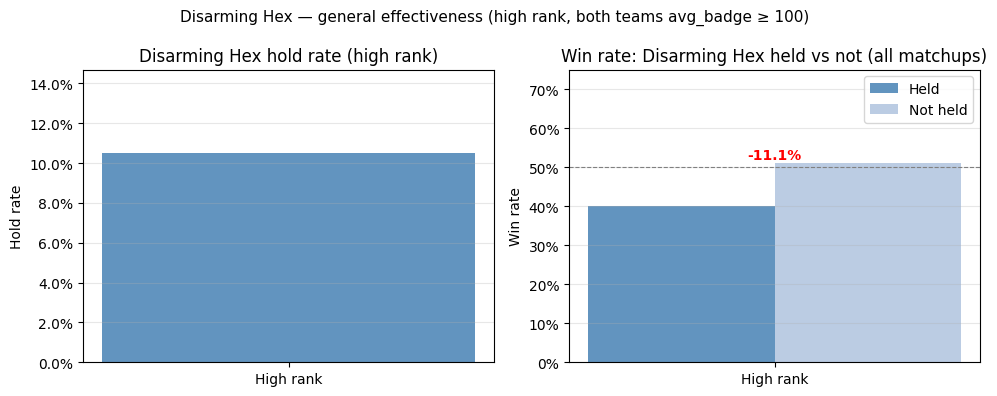

In [7]:
# Per (match, team): did they hold Disarming Hex?
disarming_hex_held = (
    items_df[(items_df['item_id'] == DISARMING_HEX_ID) & items_df['held']]
    .groupby(['match_id', 'team'])
    .size().gt(0).astype(int)
    .rename('held_disarming_hex')
    .reset_index()
)

outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

team_df = (
    outcomes
    .merge(badge_long,  on=['match_id', 'team'])
    .merge(disarming_hex_held, on=['match_id', 'team'], how='left')
)
team_df['held_disarming_hex'] = team_df['held_disarming_hex'].fillna(0).astype(int)

held     = team_df[team_df['held_disarming_hex'] == 1]['won']
not_held = team_df[team_df['held_disarming_hex'] == 0]['won']
summary = {
    'n_teams':     len(team_df),
    'n_held':      len(held),
    'hold_rate':   len(held) / len(team_df),
    'wr_held':     held.mean(),
    'wr_not_held': not_held.mean(),
    'wr_delta':    held.mean() - not_held.mean(),
}
display(pd.DataFrame([summary]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['High rank'], [summary['hold_rate']], color='steelblue', alpha=0.85)
axes[0].set_ylabel('Hold rate')
axes[0].set_title('Disarming Hex hold rate (high rank)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].set_ylim(0, max(summary['hold_rate'] * 1.4, 0.1))
axes[0].grid(axis='y', alpha=0.3)

w = 0.35
x = np.array([0])
axes[1].bar(x - w/2, [summary['wr_held']],     w, label='Held',     color='steelblue',      alpha=0.85)
axes[1].bar(x + w/2, [summary['wr_not_held']], w, label='Not held', color='lightsteelblue', alpha=0.85)
delta = summary['wr_delta']
color = 'green' if delta > 0 else 'red'
axes[1].annotate(f"{delta:+.1%}",
                 xy=(0, max(summary['wr_held'], summary['wr_not_held']) + 0.01),
                 ha='center', fontsize=10, color=color, fontweight='bold')
axes[1].axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_xticks(x); axes[1].set_xticklabels(['High rank'])
axes[1].set_ylim(0, 0.75); axes[1].set_ylabel('Win rate')
axes[1].set_title('Win rate: Disarming Hex held vs not (all matchups)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Disarming Hex — general effectiveness (high rank, both teams avg_badge ≥ 100)', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Which heroes build Disarming Hex regardless of matchup?

If certain heroes treat it as a core item, their presence inflates the counter-item signal.

,hero_name,games,times_held,hold_rate,buy_rate
30,Paige,5909,634,0.107,0.116
35,Rem,3309,279,0.084,0.088
9,Kelvin,3139,209,0.067,0.068
31,The Doorman,4019,196,0.049,0.052
25,Sinclair,2582,107,0.041,0.044
17,Ivy,5053,162,0.032,0.035
7,Paradox,5292,163,0.031,0.032
21,Viscous,3867,98,0.025,0.026
8,Dynamo,5663,141,0.025,0.027
12,Bebop,8516,187,0.022,0.023


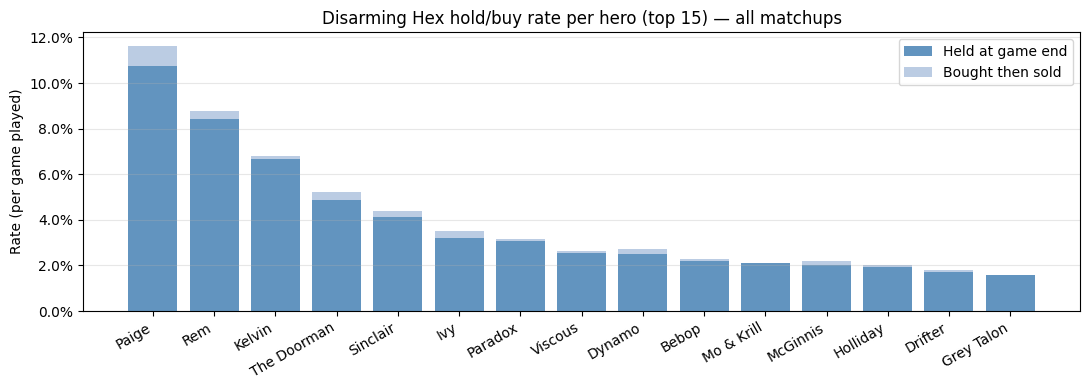

In [8]:
disarming_hex_by_hero = (
    items_df[items_df['item_id'] == DISARMING_HEX_ID]
    .groupby('hero_id')
    .agg(times_bought=('held', 'count'), times_held=('held', 'sum'))
    .reset_index()
)
disarming_hex_by_hero['hero_name']  = disarming_hex_by_hero['hero_id'].map(hero_id_to_name)
hero_games                   = players_df.groupby('hero_id').size().rename('games')
disarming_hex_by_hero               = disarming_hex_by_hero.merge(hero_games, on='hero_id')
disarming_hex_by_hero['hold_rate']  = disarming_hex_by_hero['times_held']  / disarming_hex_by_hero['games']
disarming_hex_by_hero['buy_rate']   = disarming_hex_by_hero['times_bought'] / disarming_hex_by_hero['games']
disarming_hex_by_hero               = disarming_hex_by_hero.sort_values('hold_rate', ascending=False)

display(disarming_hex_by_hero[['hero_name', 'games', 'times_held', 'hold_rate', 'buy_rate']].round(3))

top = disarming_hex_by_hero.head(15)
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(top))
ax.bar(x, top['hold_rate'], color='steelblue', alpha=0.85, label='Held at game end')
ax.bar(x, top['buy_rate'] - top['hold_rate'], bottom=top['hold_rate'],
       color='lightsteelblue', alpha=0.85, label='Bought then sold')
ax.set_xticks(x); ax.set_xticklabels(top['hero_name'], rotation=30, ha='right')
ax.set_ylabel('Rate (per game played)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title('Disarming Hex hold/buy rate per hero (top 15) — all matchups')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. The 2×2 breakdown: Haze present × Disarming Hex held

Four cells, each showing win rate and count. This separates:
- Teams that bought Dispel specifically because Haze was there
- Teams that bought it regardless
- Teams facing Haze who didn't buy it

,enemy_haze,held_disarming_hex,n,wins,win_rate
0,Haze absent,Disarming Hex NOT held,17933,9371,0.523
1,Haze absent,Disarming Hex held,1803,749,0.415
2,Haze present,Disarming Hex NOT held,9224,4531,0.491
3,Haze present,Disarming Hex held,1382,525,0.380


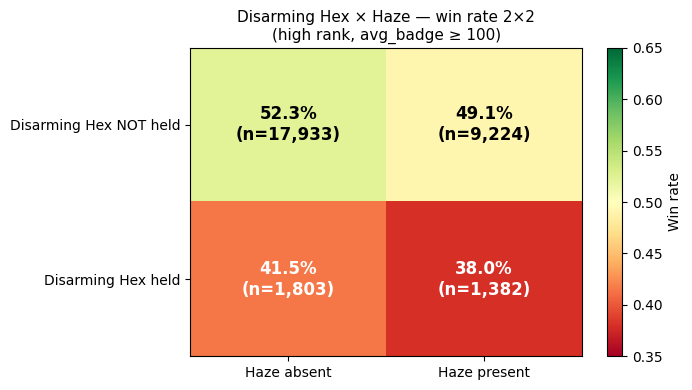

In [9]:
# Enemy Haze flag per (match, team)
haze_on_enemy = (
    players_df[players_df['hero_id'] == HAZE_ID][['match_id', 'team']]
    .assign(enemy_haze=1)
    .assign(team=lambda df: df['team'].map(OTHER_TEAM))
)

team_df2 = team_df.merge(haze_on_enemy, on=['match_id', 'team'], how='left')
team_df2['enemy_haze'] = team_df2['enemy_haze'].fillna(0).astype(int)

grid = (
    team_df2
    .groupby(['enemy_haze', 'held_disarming_hex'])
    .agg(n=('won', 'count'), wins=('won', 'sum'))
    .assign(win_rate=lambda d: d['wins'] / d['n'])
    .reset_index()
)
grid['enemy_haze'] = grid['enemy_haze'].map({0: 'Haze absent', 1: 'Haze present'})
grid['held_disarming_hex']    = grid['held_disarming_hex'].map({0: 'Disarming Hex NOT held', 1: 'Disarming Hex held'})
display(grid.round(3))

# Heatmap-style 2x2
pivot_wr = grid.pivot(index='held_disarming_hex', columns='enemy_haze', values='win_rate')
pivot_n  = grid.pivot(index='held_disarming_hex', columns='enemy_haze', values='n')

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pivot_wr.values, cmap='RdYlGn', vmin=0.35, vmax=0.65, aspect='auto')
ax.set_xticks([0, 1]); ax.set_xticklabels(pivot_wr.columns, fontsize=10)
ax.set_yticks([0, 1]); ax.set_yticklabels(pivot_wr.index,   fontsize=10)
for i in range(2):
    for j in range(2):
        wr = pivot_wr.values[i, j]
        n  = int(pivot_n.values[i, j])
        ax.text(j, i, f'{wr:.1%}\n(n={n:,})', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if wr < 0.42 or wr > 0.58 else 'black')
plt.colorbar(im, ax=ax, label='Win rate')
ax.set_title('Disarming Hex × Haze — win rate 2×2\n(high rank, avg_badge ≥ 100)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Core builders vs situational buyers

Split the Disarming Hex holders into:
- **Core builders**: heroes whose hold rate ≥ 20% (they build it most games)
- **Situational buyers**: everyone else

Then check whether the win rate difference against Haze comes from core builders (confound) or situational buyers (genuine counter signal).

Core Dispel builders (hold rate ≥ 20%):
Empty DataFrame
Columns: [hero_name, hold_rate]
Index: []


,group,matchup,n_held,n_not_held,wr_held,wr_not_held,wr_delta
0,Core builder on team,Haze present,0,0,NaN,NaN,NaN
1,Core builder on team,Haze absent,0,0,NaN,NaN,NaN
2,No core builder,Haze present,1382,9224,0.380,0.491,-0.111
3,No core builder,Haze absent,1803,17933,0.415,0.523,-0.107


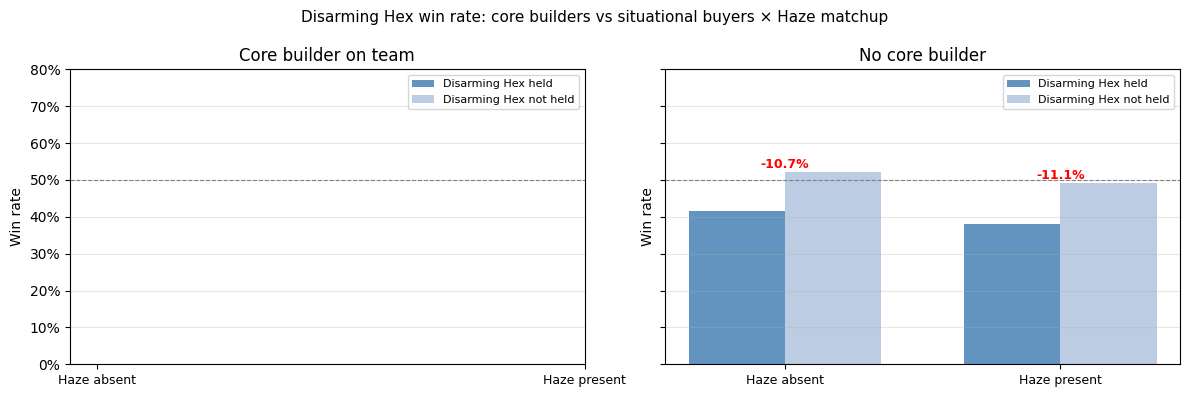

In [10]:
CORE_THRESHOLD = 0.20

core_heroes = set(
    disarming_hex_by_hero[disarming_hex_by_hero['hold_rate'] >= CORE_THRESHOLD]['hero_id']
)
print(f'Core Dispel builders (hold rate ≥ {CORE_THRESHOLD:.0%}):')
print(disarming_hex_by_hero[disarming_hex_by_hero['hold_rate'] >= CORE_THRESHOLD][['hero_name', 'hold_rate']].to_string(index=False))

# Tag each player's team as containing a core builder or not
has_core_builder = (
    players_df[players_df['hero_id'].isin(core_heroes)]
    .groupby(['match_id', 'team'])
    .size().gt(0).astype(int)
    .rename('has_core_builder')
    .reset_index()
)

team_df3 = team_df2.merge(has_core_builder, on=['match_id', 'team'], how='left')
team_df3['has_core_builder'] = team_df3['has_core_builder'].fillna(0).astype(int)

rows = []
for builder_label, builder_mask in [('Core builder on team', 1), ('No core builder', 0)]:
    for inf_label, inf_mask in [('Haze present', 1), ('Haze absent', 0)]:
        grp  = team_df3[
            (team_df3['has_core_builder'] == builder_mask) &
            (team_df3['enemy_haze']   == inf_mask)
        ]
        held     = grp[grp['held_disarming_hex'] == 1]['won']
        not_held = grp[grp['held_disarming_hex'] == 0]['won']
        rows.append({
            'group':          builder_label,
            'matchup':        inf_label,
            'n_held':         len(held),
            'n_not_held':     len(not_held),
            'wr_held':        held.mean()     if len(held)     > 0 else np.nan,
            'wr_not_held':    not_held.mean() if len(not_held) > 0 else np.nan,
        })

breakdown_df = pd.DataFrame(rows)
breakdown_df['wr_delta'] = breakdown_df['wr_held'] - breakdown_df['wr_not_held']
display(breakdown_df.round(3))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
inf_labels   = ['Haze absent', 'Haze present']
group_labels = ['Core builder on team', 'No core builder']
x = np.arange(len(inf_labels))
w = 0.35

for ax, group in zip(axes, group_labels):
    sub = breakdown_df[breakdown_df['group'] == group].set_index('matchup').reindex(inf_labels)
    ax.bar(x - w/2, sub['wr_held'],     w, label='Disarming Hex held',     color='steelblue',      alpha=0.85)
    ax.bar(x + w/2, sub['wr_not_held'], w, label='Disarming Hex not held', color='lightsteelblue', alpha=0.85)
    for i, row in enumerate(sub.itertuples()):
        if pd.isna(row.wr_delta): continue
        color = 'green' if row.wr_delta > 0 else 'red'
        ax.annotate(f'{row.wr_delta:+.1%}',
                    xy=(i, max(row.wr_held or 0, row.wr_not_held or 0) + 0.01),
                    ha='center', fontsize=9, color=color, fontweight='bold')
    ax.axhline(0.5, color='grey', linewidth=0.8, linestyle='--')
    ax.set_xticks(x); ax.set_xticklabels(inf_labels, fontsize=9)
    ax.set_ylim(0, 0.80); ax.set_ylabel('Win rate')
    ax.set_title(group)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

fig.suptitle('Disarming Hex win rate: core builders vs situational buyers × Haze matchup',
             fontsize=11)
plt.tight_layout()
plt.show()